# Retake Exam 2024 - Risk based portfolio and

# Guided Solution


Below, I will examplify how to solve the problems. I will not, necessarily, provide the full solution. 

Results may depend on modelling choices. 

# Packages

Imported functions and modules are used for solving the exam.  

In [3]:
import os

from codelib.file_management.dynamic_file_pathing import get_root

root = get_root()
data_folder = os.path.join(root, "GBI Optimisation", "Data")

import sys
sys.path.insert(0,r"C:\Users\thorb\Documents\Github Repositories\AEF_thesis_GBI")

In [4]:
from typing import Union 

# numpy for working with matrices, etc. 
import numpy as np

# import pandas
import pandas as pd

# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# scipy for statistics and optimization
from scipy import optimize
from scipy import stats

# import cvxpy
import cvxpy as cp

# function to perform interpolation

"""
functions from codelib
"""

# functions for calculating moments
from codelib.Johan.statistics import moments as mom

# functions for calculating risk metrics
from codelib.Johan.portfolio_optimization import risk_metrics as rm

# functions for risk budgetting
from codelib.Johan.portfolio_optimization import risk_metrics as rb

# functions for mean-variance optimization
from codelib.Johan.portfolio_optimization import mean_variance as mvo

# cash flows
from codelib.Johan.fixed_income.cash_flows import CashFlow

# predefined plots
from codelib.Johan.visualization.base import fan_chart

# Problem 1: Portfolio optimization

Assume that the yearly linear return follows a log-normal distribution. The excel-file _data.xlsx_ contains the expected one year discrete return, the volatility and correlation of the one discrete return, and the yearly cost. 

In [5]:
"""
Load data
"""
data_path = os.path.join(data_folder, "Afkvastforventingerne.xlsx")

asset_names = pd.read_excel(data_path, sheet_name='Returns', index_col=0).index.values.flatten()
num_assets = len(asset_names)

asset_indices = {k: i for i, k in enumerate(asset_names)}

mu_linear_1y = pd.read_excel(data_path, sheet_name='Returns', index_col=0).values.flatten()

corr_mat_linear_1y = pd.read_excel(data_path, sheet_name='Correlation', index_col=0).values
corr_mat_linear_1y[np.tril_indices_from(corr_mat_linear_1y, k=-1)] = corr_mat_linear_1y.T[np.tril_indices_from(corr_mat_linear_1y, k=-1)]

vols_linear_1y = pd.read_excel(data_path, sheet_name='Volatility', index_col=0).values.flatten()
costs_linear_1y = pd.read_excel(data_path, sheet_name='Cost', index_col=0).values.flatten()

In [6]:
"""
Calculate covariance matrix
"""

cov_mat_linear_1y = mom.corr_to_cov_matrix(corr_mat_linear_1y, vols_linear_1y)

In [7]:
pd.DataFrame(cov_mat_linear_1y)

,0,1,2,3,4,5,6,7,8,9
0,0.001089,0.001129,0.000640,0.001228,0.000000,0.000000,-0.000673,-0.000482,-0.000317,0.000000
1,0.001129,0.003249,0.003870,0.003181,0.002702,0.003557,0.002326,0.000832,0.000547,0.001573
2,0.000640,0.003870,0.009409,0.006315,0.010728,0.012106,0.009894,0.005665,0.002794,0.005354
3,0.001228,0.003181,0.006315,0.008649,0.007347,0.013541,0.005692,0.002716,0.001786,0.004278
4,0.000000,0.002702,0.010728,0.007347,0.024964,0.023005,0.022562,0.009227,0.006067,0.010175
5,0.000000,0.003557,0.012106,0.013541,0.023005,0.043264,0.025459,0.012147,0.005990,0.013395
6,-0.000673,0.002326,0.009894,0.005692,0.022562,0.025459,0.041616,0.014892,0.007834,0.011261
7,-0.000482,0.000832,0.005665,0.002716,0.009227,0.012147,0.014892,0.021316,0.004205,0.004030
8,-0.000317,0.000547,0.002794,0.001786,0.006067,0.005990,0.007834,0.004205,0.009216,0.002650
9,0.000000,0.001573,0.005354,0.004278,0.010175,0.013395,0.011261,0.004030,0.002650,0.008464


## What is the $\mu$ and $\Sigma$ parameters in the log-normal distribution of the yearly log prices?

Assume discrete return after cost

We have that 

$$
E[1 + R] = e^{\mu + \frac{1}{2} \text{diag}(\Sigma)} - 1
$$

and 

$$
Cov[1 + R] = (e^{\Sigma} - I) \odot E[1 + R] E[1 + R]^\top
$$

From the latter, we can easily derive that 

$$
\Sigma   = \log ((Cov[1 + R] + E[1 + R] E[1 + R]^\top) \odot \frac{1}{E[1 + R] E[1 + R]^\top}) = \log (1 + Cov[1 + R] \odot \frac{1}{E[1 + R] E[1 + R]^\top})
$$

Knowing $\Sigma$, we can define 

$$
\mu = \log(E[1 + R]) - \frac{1}{2} \text{diag}(\Sigma)
$$

In [8]:
"""
Define function to convert between normal and log-normal parameters
"""

def convert_to_lognormal(mean, cov_mat): 

    cov_mat_log = np.log(1 + cov_mat / np.outer(mean, mean))
    
    mu_log = np.log(mean) - 0.5 * np.diag(cov_mat_log)

    return mu_log, cov_mat_log

In [9]:
"""mu_log_1y, cov_mat_log_1y = convert_to_lognormal(mean=1 + mu_linear_1y - costs_linear_1y, cov_mat=cov_mat_linear_1y)
vols_log_1y = np.sqrt(np.diag(cov_mat_log_1y))"""

'mu_log_1y, cov_mat_log_1y = convert_to_lognormal(mean=1 + mu_linear_1y - costs_linear_1y, cov_mat=cov_mat_linear_1y)\nvols_log_1y = np.sqrt(np.diag(cov_mat_log_1y))'

In [10]:
mu_log_1y, cov_mat_log_1y = convert_to_lognormal(mean=1 + mu_linear_1y, cov_mat=cov_mat_linear_1y)
vols_log_1y = np.sqrt(np.diag(cov_mat_log_1y))

In [11]:
cov_mat_log_1y

array([[ 0.00102795,  0.0010571 ,  0.00059236,  0.00113663,  0.        ,
         0.        , -0.00059874, -0.00043974, -0.00029325,  0.        ],
       [ 0.0010571 ,  0.00301673,  0.00354818,  0.00291958,  0.00243199,
         0.0031533 ,  0.0020497 ,  0.00075324,  0.00050242,  0.00144516],
       [ 0.00059236,  0.00354818,  0.00849803,  0.00571671,  0.00950361,
         0.0105602 ,  0.00858415,  0.00505298,  0.00253067,  0.00484945],
       [ 0.00113663,  0.00291958,  0.00571671,  0.00782913,  0.00652429,
         0.01181601,  0.0049518 ,  0.0024278 ,  0.00161982,  0.00388014],
       [ 0.        ,  0.00243199,  0.00950361,  0.00652429,  0.02157021,
         0.01960383,  0.01910845,  0.00806462,  0.00538574,  0.00902449],
       [ 0.        ,  0.0031533 ,  0.0105602 ,  0.01181601,  0.01960383,
         0.03602637,  0.02122161,  0.01044783,  0.0052396 ,  0.01168969],
       [-0.00059874,  0.0020497 ,  0.00858415,  0.0049518 ,  0.01910845,
         0.02122161,  0.03424232,  0.01271218

In [12]:
mu_log_1y

array([0.02807348, 0.03482356, 0.04454115, 0.04392276, 0.05687355,
       0.06448804, 0.07180505, 0.05366528, 0.04462794, 0.04400617])

### Validate by simulations that the obtained parameters are consistent with provided expected returns, volatilities and covariance matrix

In [13]:
mom.calculate_log_norm_mean(mu_log_1y, cov_mat_log_1y) - 1.0 - (mu_linear_1y)

array([-8.67361738e-17, -7.63278329e-17,  4.16333634e-17, -6.93889390e-17,
        5.55111512e-17,  8.32667268e-17, -2.77555756e-17, -5.55111512e-17,
        4.16333634e-17, -6.93889390e-17])

In [14]:
mom.calculate_log_norm_cov_mat(mu_log_1y, cov_mat_log_1y) - cov_mat_linear_1y

array([[-1.73472348e-18, -5.61616725e-17,  9.63855731e-17,
         1.53956708e-17,  0.00000000e+00,  0.00000000e+00,
        -2.03830008e-17,  3.33934269e-17, -3.65376132e-17,
         0.00000000e+00],
       [-5.61616725e-17,  8.45677695e-17, -6.89552582e-17,
        -7.67615138e-17,  8.15320034e-17,  1.82145965e-17,
        -1.23165367e-16, -4.94396191e-17, -2.71050543e-18,
         9.97465999e-17],
       [ 9.63855731e-17, -6.89552582e-17, -1.05818132e-16,
        -1.10154941e-16,  4.85722573e-17, -7.97972799e-17,
         2.60208521e-17,  9.19403442e-17,  6.07153217e-18,
        -6.41847686e-17],
       [ 1.53956708e-17, -7.67615138e-17, -1.10154941e-16,
        -9.88792381e-17,  4.25007252e-17,  3.46944695e-17,
        -9.97465999e-17,  6.02816408e-17,  1.01264483e-16,
        -1.01481323e-16],
       [ 0.00000000e+00,  8.15320034e-17,  4.85722573e-17,
         4.25007252e-17, -8.67361738e-17,  4.16333634e-17,
        -3.46944695e-18,  4.16333634e-17, -1.73472348e-17,
        -1.

In [15]:
"""
Simulation - choose an asset index
"""

asset_idx = 0
num_sim = 100_000

sim_log_norm_1y = stats.lognorm(s=vols_log_1y[asset_idx], scale=np.exp(mu_log_1y[asset_idx])).rvs(num_sim) - 1.0

In [16]:
sim_log_norm_1y.mean()

0.02875966957070442

In [17]:
mu_linear_1y[asset_idx]

0.029

In [18]:
"""mu_linear_1y - costs_linear_1y"""

'mu_linear_1y - costs_linear_1y'

### Weekly parameters

Assume independence. 

Since log-returns aggregrate across time, we can simply multiply with the time step. 

In [19]:
"""
Weekly parameters
"""

# time step 
dt = 1.0 / 52.0 

# Calculate weekly parameters of the log-normal distribution
mu_log_weekly, cov_mat_log_weekly = mu_log_1y * dt, cov_mat_log_1y * dt
vols_log_weekly = np.sqrt(np.diag(cov_mat_log_weekly))

## Simulate the log-returns and prices for the next 10 years

In [20]:
def simulate_price_evolution(initial_values: np.ndarray,
               mu: np.ndarray, 
               cov_mat: np.ndarray,
               num_sim: int, 
               num_per: int):
    
    # number of risk drivers
    num_risk_drivers = len(mu)
    
    # define matrix to store values
    risk_drivers = np.zeros((num_sim, 1 + num_per, num_risk_drivers))
    risk_drivers[:, 0, :] = np.log(initial_values)
    
    # simulate normal invariants
    eps = stats.multivariate_normal(mean=mu, cov=cov_mat).rvs(size=(num_sim, num_per))
    
    # create risk drives at horizon
    risk_drivers[:, 1:, :] = np.log(initial_values) + np.cumsum(eps, axis=1)
    
    return np.exp(risk_drivers)

In [21]:
def calculate_analytical_percentile(mu: np.ndarray,
                                    vol: np.ndarray, 
                                    horizon=1.0,
                                    q=0.5) -> float: 
    """
    Function calculating the q-percentile of a constant-mix portfolio. 
    """
    
    if horizon == 0.0:
        return np.ones_like(q)
    else: 
        return stats.lognorm.ppf(q, s=vol * np.sqrt(horizon), scale=np.exp(mu * horizon))

In [22]:
"""
Inputs
"""
years_sim = 10
num_sim = 10_000
num_per = 52 * years_sim

"""
Simulate prices
"""
time_points = np.arange(0, years_sim + dt, dt)
sim_prices = simulate_price_evolution(np.ones_like(asset_names, dtype=float), mu_log_weekly, cov_mat_log_weekly, num_sim, num_per)

"""
Store in dict
"""

sim_data = {asset_names[i] : sim_prices[:, :, i] for i in range(num_assets)}

In [23]:
"""len_dic=len(sim_data)

for i, (name, data) in enumerate(sim_data.items(), start = 1):
    print(f"Outputting {name} to excel [{i}/{len_dic}]")
    df = pd.DataFrame(data)
    output_path = os.path.join(root, "Simulation", "JohanSim", f"{name}.xlsx")
    df.to_excel(output_path, index=False)
    print(f"Output completed \n")"""

'len_dic=len(sim_data)\n\nfor i, (name, data) in enumerate(sim_data.items(), start = 1):\n    print(f"Outputting {name} to excel [{i}/{len_dic}]")\n    df = pd.DataFrame(data)\n    output_path = os.path.join(root, "Simulation", "JohanSim", f"{name}.xlsx")\n    df.to_excel(output_path, index=False)\n    print(f"Output completed \n")'

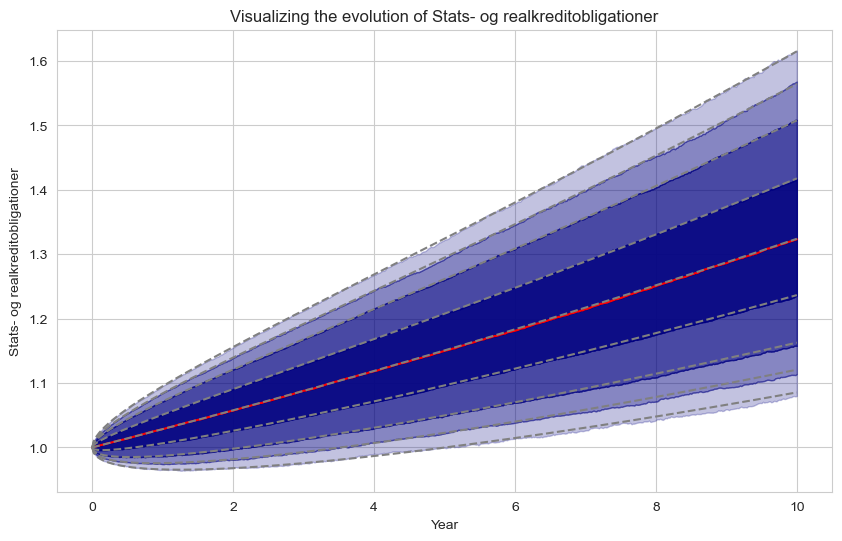

In [24]:
asset_id = 'Stats- og realkreditobligationer'
asset_idx = asset_indices[asset_id]

# calculate simulated percentiles for log-fx
percentiles = np.percentile(sim_data[asset_id], [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

# calculating analytical percentiles
true_percentiles = np.array([calculate_analytical_percentile(mu_log_weekly[asset_idx], vols_log_weekly[asset_idx], t,
                             q=[0.025, 0.05 , 0.1  , 0.25 , 0.5  , 0.75 , 0.9  , 0.95 , 0.975]) for t in time_points / dt])

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")
ax.plot(time_points, true_percentiles, color="gray", linestyle="--");

ax.set(ylabel=asset_id, xlabel="Year", title="Visualizing the evolution of " + asset_id); 

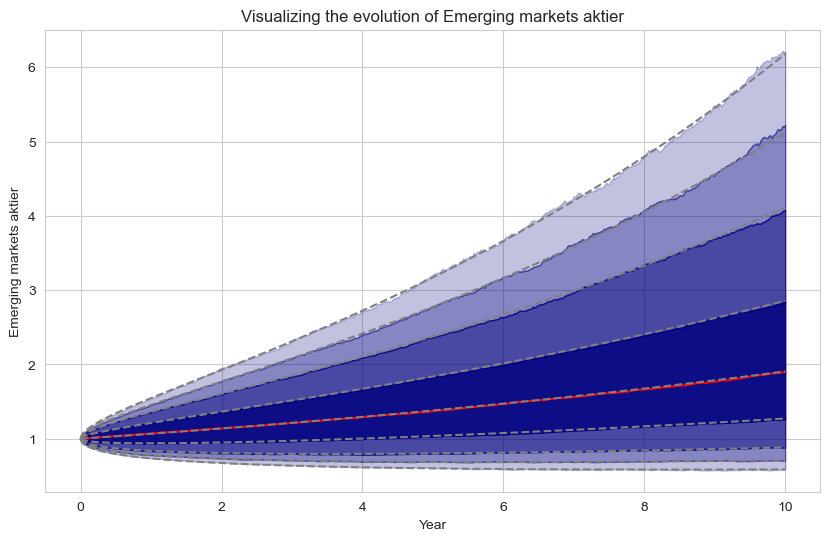

In [25]:
asset_id = 'Emerging markets aktier'
asset_idx = asset_indices[asset_id]

# calculate simulated percentiles for log-fx
percentiles = np.percentile(sim_data[asset_id], [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)
# calculating analytical percentiles
true_percentiles = np.array([calculate_analytical_percentile(mu_log_weekly[asset_idx], vols_log_weekly[asset_idx], t,
                             q=[0.025, 0.05 , 0.1  , 0.25 , 0.5  , 0.75 , 0.9  , 0.95 , 0.975]) for t in time_points / dt])

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")
ax.plot(time_points, true_percentiles, color="gray", linestyle="--");

ax.set(ylabel=asset_id, xlabel="Year", title="Visualizing the evolution of " + asset_id); 

## Calculate risk measures for the assets on a weekly and yearly horizon

We provide the mean, standard deviation, skewness, kurtosis (excess), VaR and CVaR

In [26]:
def calculate_analytical_metrics(mu, vol, alpha=0.05):
        
    dict = {}
    
    dist = stats.lognorm(s=vol, scale=np.exp(mu), loc=-1)

    mean, var, skew, kurt = dist.stats(moments='mvsk')
    std = np.sqrt(var)

    # Value at Risk
    VaR = -1 * dist.ppf(0.05)

    # Conditional Value at Risk
    CVaR = -((np.exp(mu + vol**2 / 2) * stats.norm.cdf(stats.norm.ppf(alpha) - vol)) / alpha - 1)
    
    return {
        'Expected value': mean,
         'Standard deviation': std,
         'Kurtosis': kurt, 
         'Skewness': skew, 
         'VaR({}%)'.format(alpha*100): VaR, 
         'CVaR({}%)'.format(alpha*100): CVaR, 
         'IR': mean / std}

### Weekly horizon

In [27]:
results_weekly = []

for asset, mu, vol in zip(asset_names, mu_log_weekly, vols_log_weekly): 

    metrics = calculate_analytical_metrics(mu, vol)
    metrics['Asset'] = asset

    results_weekly.append(metrics)

df_metrics_weekly = pd.DataFrame(results_weekly).set_index('Asset')

In [28]:
df_metrics_weekly * 100

,Expected value,Standard deviation,Kurtosis,Skewness,VaR(5.0%),CVaR(5.0%),IR
Asset,,,,,,,
Stats- og realkreditobligationer,0.054991,0.444863,0.031630,1.333864,0.675052,0.859279,12.361335
Investment-grade obligationer,0.069894,0.762213,0.092830,2.285087,1.178863,1.492488,9.169809
High-yield obligationer,0.093871,1.279625,0.261539,3.835483,1.996873,2.517893,7.335843
Emerging markets statsobligationer,0.092037,1.228206,0.240949,3.681413,1.915240,2.415846,7.493631
Globale aktier (developed markets),0.130197,2.039556,0.664095,6.111556,3.188741,4.006419,6.383619
Emerging markets aktier,0.158782,2.636774,1.109608,7.899605,4.118263,5.162538,6.021834
Private equity,0.171158,2.570953,1.054608,7.701370,4.000609,5.020198,6.657386
Infrastruktur,0.121179,1.894706,0.573188,5.677915,2.964433,3.726287,6.395650
Ejendomme,0.093871,1.266487,0.256196,3.796100,1.975551,2.491359,7.411942


In [29]:
"""
Covariance matrix and expectation vector 
"""

mu_l_weekly = mom.calculate_log_norm_mean(mu_log_weekly, cov_mat_log_weekly) - 1.0
cov_mat_l_weekly = mom.calculate_log_norm_cov_mat(mu_log_weekly, cov_mat_log_weekly)

In [30]:
mu_l_weekly

array([0.00054991, 0.00069894, 0.00093871, 0.00092037, 0.00130197,
       0.00158782, 0.00171158, 0.00121179, 0.00093871, 0.00092037])

### Yearly horizon

In [31]:
results_1y = []

for asset, mu, vol in zip(asset_names, mu_log_1y, vols_log_1y): 

    metrics = calculate_analytical_metrics(mu, vol)
    metrics['Asset'] = asset

    results_1y.append(metrics)

df_metrics_1y = pd.DataFrame(results_1y).set_index('Asset')

In [32]:
df_metrics_1y * 100

,Expected value,Standard deviation,Kurtosis,Skewness,VaR(5.0%),CVaR(5.0%),IR
Asset,,,,,,,
Stats- og realkreditobligationer,2.9,3.3,1.647160,9.624290,2.436172,3.727753,87.878788
Investment-grade obligationer,3.7,5.7,4.847770,16.506482,5.400661,7.528002,64.912281
High-yield obligationer,5.0,9.7,13.764408,27.793126,10.155455,13.500584,51.546392
Emerging markets statsobligationer,4.9,9.3,12.668737,26.666441,9.662527,12.895276,52.688172
Globale aktier (developed markets),7.0,15.8,35.606638,44.621039,16.864867,21.700000,44.303797
Emerging markets aktier,8.6,20.8,60.741377,58.161151,21.941784,27.720057,41.346154
Private equity,9.3,20.4,57.582300,56.642855,20.750561,26.479542,45.588235
Infrastruktur,6.5,14.6,30.603305,41.384398,15.699096,20.271327,44.520548
Ejendomme,5.0,9.6,13.479859,27.504998,10.007676,13.325051,52.083333


In [33]:
"""
Covariance matrix and expectation vector 
"""

mu_l_1y = mom.calculate_log_norm_mean(mu_log_1y, cov_mat_log_1y) - 1.0
cov_mat_l_1y = mom.calculate_log_norm_cov_mat(mu_log_1y, cov_mat_log_1y)

## Calculate risk measures for three different portfolios at weekly and yearly horizon

### Define portfolios

In [34]:
"""
Equally weighted portfolio
"""

w_eq = np.ones(num_assets) / num_assets

In [35]:
"""
Minimum variance portfolios
"""

def calculate_min_var_portfolio(cov_mat: np.ndarray): 
        
    # define target variable
    num_assets = cov_mat.shape[0]
    w = cp.Variable(num_assets)
    
    # define constraints
    constraints = [cp.sum(w) == 1.0, w>=0]
    
    # define problem 
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cov_mat)), constraints)
    
    # solve
    prob.solve()
    
    if prob.status == 'optimal':
        return w.value
    else:    
        return np.ones(num_assets) * np.nan

# minimum variance portfolio (weekly)
w_min_var_weekly = calculate_min_var_portfolio(cov_mat_l_weekly) 

# minimum variance portfolio (yearly)
w_min_var_1y = calculate_min_var_portfolio(cov_mat_l_1y)

In [36]:
pd.DataFrame(w_min_var_weekly, index=asset_names)

,0
Stats- og realkreditobligationer,8.155424e-01
Investment-grade obligationer,-1.245283e-17
High-yield obligationer,6.201095e-19
Emerging markets statsobligationer,-4.884099e-18
Globale aktier (developed markets),1.791578e-17
Emerging markets aktier,2.431617e-17
Private equity,2.329597e-17
Infrastruktur,3.171034e-02
Ejendomme,9.279455e-02
Hedgefonde,5.995276e-02


In [37]:
pd.DataFrame(w_min_var_1y, index=asset_names)

,0
Stats- og realkreditobligationer,8.216949e-01
Investment-grade obligationer,-3.994803e-21
High-yield obligationer,1.951874e-22
Emerging markets statsobligationer,-1.560295e-21
Globale aktier (developed markets),5.945302e-21
Emerging markets aktier,8.232117e-21
Private equity,7.936406e-21
Infrastruktur,2.970174e-02
Ejendomme,9.039388e-02
Hedgefonde,5.820947e-02


In [38]:
"""
Max Sharpe - old
"""

def calculate_max_sharpe_portfolio(mu, cov_mat, rf=0): 

    # negative sharpe ratio
    neg_sharpe_ratio = lambda w: -(mvo.portfolio_mean(w, mu) - rf) / mvo.portfolio_std(w, cov_mat)

    # constraints and bounds
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0.0, 1.0) for _ in range(len(mu))]

    # starting values
    w0 = np.ones(len(mu)) / len(mu)

    # minimize negative sharpe ratio
    res = optimize.minimize(neg_sharpe_ratio, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    
    return res.x

def calculate_mean_var_portfolio(mu: np.ndarray, cov_mat: np.ndarray, target): 
        
    # define target variable
    num_assets = cov_mat.shape[0]
    w = cp.Variable(num_assets)
    
    # define constraints
    constraints = [cp.sum(w) == 1.0, w>=0, w @ mu == target]
    
    # define problem 
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cov_mat)), constraints)
    
    # solve
    prob.solve()
    
    if prob.status == 'optimal':
        return w.value
    else:    
        return np.ones(num_assets) * np.nan

# low
w_mvo_low = calculate_mean_var_portfolio(mu_l_1y, cov_mat_l_1y, 0.035)

# medium
w_mvo_medium = calculate_mean_var_portfolio(mu_l_1y, cov_mat_l_1y, 0.045)

# high
w_mvo_high = calculate_mean_var_portfolio(mu_l_1y, cov_mat_l_1y, 0.065)

In [39]:
pd.DataFrame(w_mvo_low, index=asset_names)

,0
Stats- og realkreditobligationer,7.571253e-01
Investment-grade obligationer,-3.342107e-21
High-yield obligationer,7.984928e-22
Emerging markets statsobligationer,3.526468e-22
Globale aktier (developed markets),4.323328e-21
Emerging markets aktier,9.241622e-21
Private equity,5.061279e-03
Infrastruktur,5.062790e-02
Ejendomme,1.097639e-01
Hedgefonde,7.742164e-02


In [40]:
pd.DataFrame(w_mvo_medium, index=asset_names)

,0
Stats- og realkreditobligationer,5.101962e-01
Investment-grade obligationer,4.389091e-02
High-yield obligationer,8.684846e-20
Emerging markets statsobligationer,4.194188e-02
Globale aktier (developed markets),2.248800e-20
Emerging markets aktier,2.753538e-02
Private equity,9.122202e-02
Infrastruktur,9.592574e-02
Ejendomme,1.632254e-01
Hedgefonde,2.606243e-02


In [41]:
pd.DataFrame(w_mvo_high, index=asset_names)

,0
Stats- og realkreditobligationer,7.880433e-21
Investment-grade obligationer,2.408838e-02
High-yield obligationer,2.490447e-21
Emerging markets statsobligationer,2.572595e-01
Globale aktier (developed markets),1.064897e-21
Emerging markets aktier,5.454612e-02
Private equity,2.538872e-01
Infrastruktur,1.793067e-01
Ejendomme,2.309122e-01
Hedgefonde,7.712836e-21


### Calculate performance and risk metrics

In [42]:
ret_mat_weekly = sim_prices[:, 1, :] - 1.0
ret_mat_1y = sim_prices[:, 52, :] - 1.0

In [43]:
def calculate_portfolio_metrics(w, mu, cov_mat, ret_mat, asset_names=asset_names, alpha=0.05, use_analytical=False):

    # number of assets
    num_assets = len(w)

    # calculate portfolio return 
    port_ret = ret_mat @ w
    
    # Create data frame
    columns = [("Exposure", "Portfolio weights"),
               ("CVaR(5%)", "Standalone"), ("CVaR(5%)", "RC"), ("CVaR(5%)", "MR"),
               ("Expected return", "Standalone"), ("Expected return", "Contribution"),
               ("Std.", "Standalone"), ("Std.", "RC"), ("Std.", "MR"),
               ("Risk-Return", "RoRAC CVaR(5%)"), ("Risk-Return", "RoRAC Std."), 
               #("Risk-Return", "RoMR CVaR(5%)"), ("Risk-Return", "RoMR Std."), 
               ("Risk-Return", "IR CVaR(5%)"), ("Risk-Return", "IR Std.")] # ("Risk-Return", "DI"), 
    
    multi_index = pd.MultiIndex.from_tuples(columns, names=["Category", "Subcategory"])
    
    df_res = pd.DataFrame(columns=multi_index, index=pd.Index(['Portfolio'] + list(asset_names)))

    # exposure
    df_res.loc[:, ('Exposure','Portfolio weights')] = np.r_[1.0, w]

    # CVaR
    df_res.loc['Portfolio', ("CVaR(5%)", "Standalone")] = -rm.calculate_conditional_value_at_risk(port_ret, p=0.05)
    df_res.loc[asset_names, ("CVaR(5%)", "Standalone")] = [-rm.calculate_conditional_value_at_risk(ret_mat[:, i], p=0.05) for i in range(num_assets)]

    df_res.loc[asset_names, ("CVaR(5%)", "RC")] = -rb.calculate_risk_contributions_cvar(w, ret_mat)
    df_res.loc['Portfolio', ("CVaR(5%)", "RC")] = df_res.loc['Portfolio', ("CVaR(5%)", "Standalone")]
    
    df_res.loc[asset_names, ("CVaR(5%)", "MR")] = -rb.calculate_marginal_risks_cvar(w, ret_mat)

    # expected return 
    if use_analytical: 
        df_res.loc[asset_names, ("Expected return", "Standalone")] = mu
        df_res.loc['Portfolio', ("Expected return", "Standalone")] = w @ mu

        df_res.loc[asset_names, ("Expected return", "Contribution")] = mu * w
        df_res.loc['Portfolio', ("Expected return", "Contribution")] = w @ mu
    else: 
        mean_ret = np.mean(ret_mat, axis=0)
        
        df_res.loc[asset_names, ("Expected return", "Standalone")] = mean_ret
        df_res.loc['Portfolio', ("Expected return", "Standalone")] = np.mean(port_ret)

        df_res.loc[asset_names, ("Expected return", "Contribution")] = mean_ret * w
        df_res.loc['Portfolio', ("Expected return", "Contribution")] = np.mean(port_ret)

    # standard devation
    if use_analytical: 
        df_res.loc[asset_names, ("Std.", "Standalone")] = np.sqrt(np.diag(cov_mat))
        df_res.loc['Portfolio', ("Std.", "Standalone")] = np.sqrt(w @ cov_mat @ w)

        df_res.loc[asset_names, ("Std.", "RC")] = rb.calculate_risk_contributions_std(w, cov_mat)
        df_res.loc['Portfolio', ("Std.", "RC")] = np.sqrt(w @ cov_mat @ w)

        df_res.loc[asset_names, ("Std.", "MR")] = rb.calculate_marginal_risks_std(w, cov_mat)
    
    else: 
        cov_mat_est = np.cov(ret_mat.T)
        
        df_res.loc[asset_names, ("Std.", "Standalone")] = np.sqrt(np.diag(cov_mat_est))
        df_res.loc['Portfolio', ("Std.", "Standalone")] = np.sqrt(w @ cov_mat_est @ w)

        df_res.loc[asset_names, ("Std.", "RC")] = rb.calculate_marginal_risks_std(w, cov_mat_est)
        df_res.loc['Portfolio', ("Std.", "RC")] = np.sqrt(w @ cov_mat_est @ w)

        df_res.loc[asset_names, ("Std.", "MR")] = rb.calculate_risk_contributions_std(w, cov_mat_est)

    # risk-return 
    df_res.loc[:, ("Risk-Return", "RoRAC CVaR(5%)")] = df_res.loc[:, ("Expected return", "Contribution")] / df_res.loc[:, ("CVaR(5%)", "RC")]
    df_res.loc[:, ("Risk-Return", "RoRAC Std.")] = df_res.loc[:, ("Expected return", "Contribution")] / df_res.loc[:, ("Std.", "RC")]

    #df_res.loc[asset_names, ("Risk-Return", "RoMR CVaR(5%)")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("CVaR(5%)", "MR")]
    #df_res.loc[asset_names, ("Risk-Return", "RoMR Std.")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("Std.", "MR")]
    
    df_res.loc[:, ("Risk-Return", "IR CVaR(5%)")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("CVaR(5%)", "Standalone")]
    df_res.loc[:, ("Risk-Return", "IR Std.")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("Std.", "Standalone")]

    # df_res.loc[asset_names, ("Expected return", "Contribution")] / df_res.loc[asset_names, ("Expected return", "Contribution")]
    
    return df_res

In [44]:
"""
Equally weighted portfolio
"""

df_port_metrics_eq = calculate_portfolio_metrics(w_eq, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_eq

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

In [45]:
"""
Minimum variance portfolio
"""

df_port_metrics_min_var = calculate_portfolio_metrics(w_min_var_1y, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_min_var

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

In [46]:
df_port_metrics_low = calculate_portfolio_metrics(w_mvo_low, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_low

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

In [47]:
df_port_metrics_medium = calculate_portfolio_metrics(w_mvo_medium, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_medium

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

In [48]:
df_port_metrics_high = calculate_portfolio_metrics(w_mvo_high, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_high

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

### Plots for visualization

In [49]:
rb.calculate_marginal_risks_std(w_min_var_1y, cov_mat_linear_1y)

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_marginal_risks_std'

In [50]:
rb.calculate_marginal_risks_std(w_eq, cov_mat_linear_1y)

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_marginal_risks_std'

## Simulate CVaR of portfolio for the next 10 year

We perform the calculation relative to the market value of the portfolio, but with updated weights. 

In [51]:
"""
Calculate portfolio value 
"""

sim_portfolio_value = sim_prices @ w_mvo_low

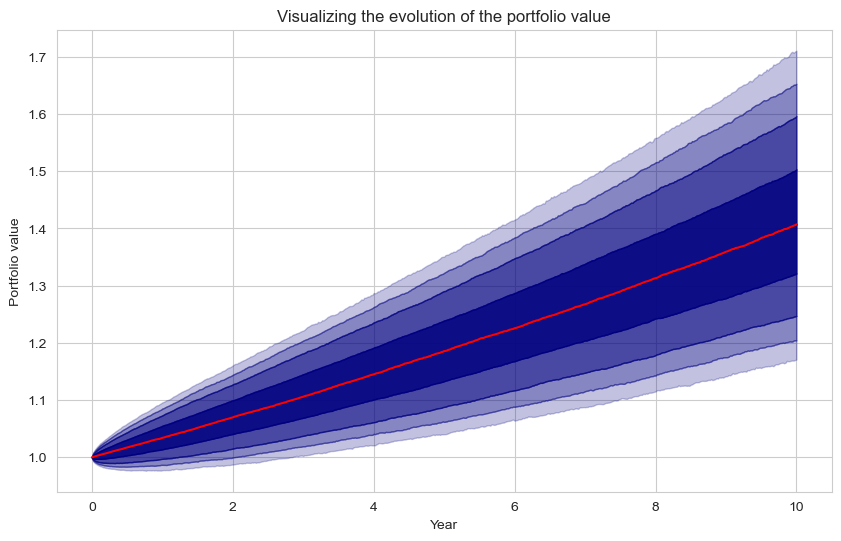

In [52]:
"""
Visualise evolution of portfolio value
"""

percentiles = np.percentile(sim_portfolio_value, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")

ax.set(ylabel='Portfolio value', xlabel="Year", title="Visualizing the evolution of the portfolio value"); 

In [53]:
"""
Evolution in portfolio weights
"""

sim_w = sim_prices * w_mvo_low[None, None, :] / sim_portfolio_value[:, :, None]


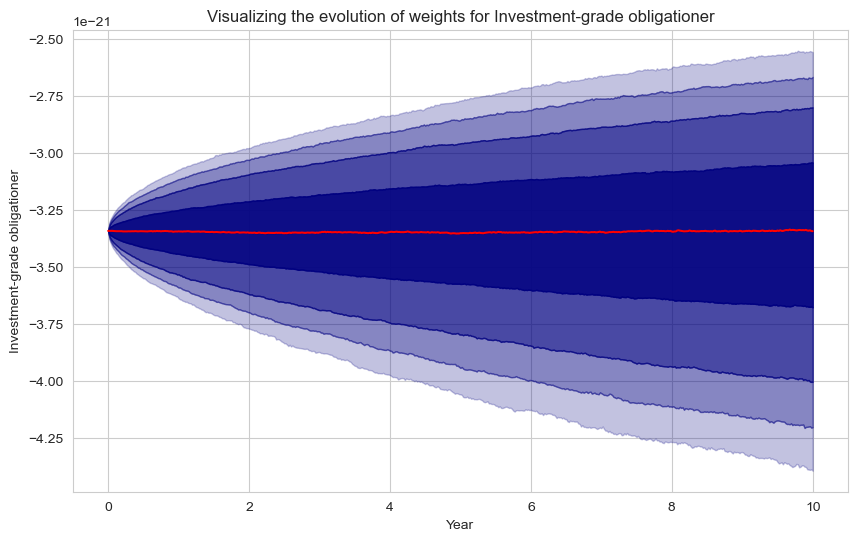

In [54]:
"""
Visualize evolution in portfolio weights
"""

asset_id = 'Investment-grade obligationer'
asset_idx = asset_indices[asset_id]

percentiles = np.percentile(sim_w[:, :, asset_idx], [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")

ax.set(ylabel=asset_id, xlabel="Year", title="Visualizing the evolution of weights for " + asset_id); 

In [55]:
from joblib import Parallel, delayed
# import multiprocessing as mp

In [56]:
"""
Simulate CVaR(5%, 1Y)
"""

horison_in_weeks = 52 * 1
num_sim_to_use = 10_000
sim_cvar = np.zeros((num_sim_to_use, horison_in_weeks + 1))
cvar_time_points = np.arange(0, horison_in_weeks * dt + dt, dt)

#for s in range(num_sim_to_use):
#    for t in range(horison_in_weeks + 1): 
#        sim_cvar[s, t] = -rm.calculate_conditional_value_at_risk(ret_mat_1y @ sim_w[s, t, :], p=0.05)

def compute_simulation_row(s):
    row = np.zeros(horison_in_weeks + 1)
    for t in range(horison_in_weeks + 1):
        # The @ operator performs matrix multiplication
        row[t] = -rm.calculate_conditional_value_at_risk(
            ret_mat_1y @ sim_w[s, t, :], p=0.05
        )
    return row

results = Parallel(n_jobs=-1)(
    delayed(compute_simulation_row)(s) for s in range(num_sim_to_use)
)

sim_cvar = np.array(results)

KeyboardInterrupt: 

In [369]:
cvar_time_points = np.arange(0, horison_in_weeks * dt + dt, dt)


In [370]:
cvar_time_points

array([0.        , 0.01923077, 0.03846154, 0.05769231, 0.07692308,
       0.09615385, 0.11538462, 0.13461538, 0.15384615, 0.17307692,
       0.19230769, 0.21153846, 0.23076923, 0.25      , 0.26923077,
       0.28846154, 0.30769231, 0.32692308, 0.34615385, 0.36538462,
       0.38461538, 0.40384615, 0.42307692, 0.44230769, 0.46153846,
       0.48076923, 0.5       , 0.51923077, 0.53846154, 0.55769231,
       0.57692308, 0.59615385, 0.61538462, 0.63461538, 0.65384615,
       0.67307692, 0.69230769, 0.71153846, 0.73076923, 0.75      ,
       0.76923077, 0.78846154, 0.80769231, 0.82692308, 0.84615385,
       0.86538462, 0.88461538, 0.90384615, 0.92307692, 0.94230769,
       0.96153846, 0.98076923, 1.        ])

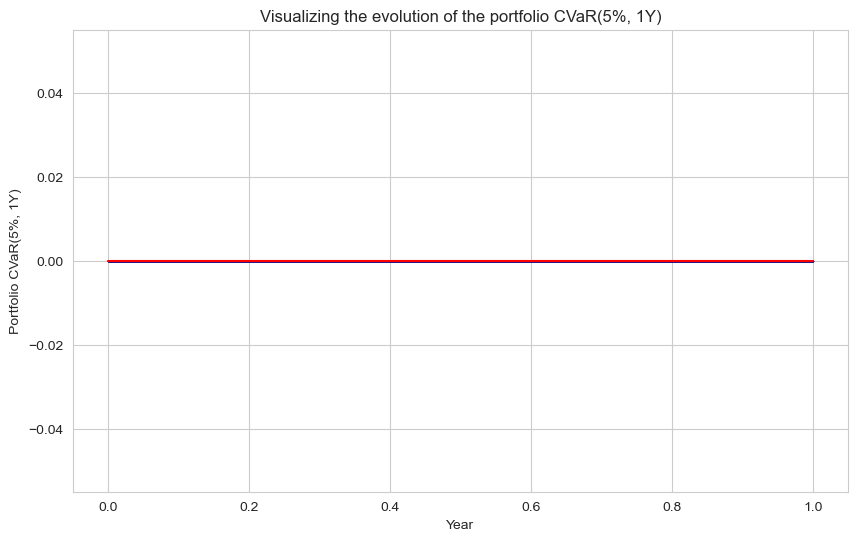

In [69]:
"""
Visualise evolution of portfolio value
"""

percentiles = np.percentile(sim_cvar * 100, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(cvar_time_points, percentiles, ax=ax, color="navy")

ax.set(ylabel='Portfolio CVaR(5%, 1Y)', xlabel="Year", title="Visualizing the evolution of the portfolio CVaR(5%, 1Y)"); 

## Distribution of realized Sharpe ratios, etc. 

In [70]:
"""
Calculate portfolio period return
"""

sim_port_ret = sim_portfolio_value[:, 1:] / sim_portfolio_value[:, :-1] - 1.0

"""
Calculate relevant metrics
"""

sim_port_std = np.std(sim_port_ret, axis=1)
sim_port_ar_ret = np.mean(sim_port_ret, axis=1)
sim_port_sharpe = sim_port_ar_ret / sim_port_std 
sim_port_geo_ret = sim_portfolio_value[:, -1]**(1 / 5.0) - 1.0

<Axes: ylabel='Density'>

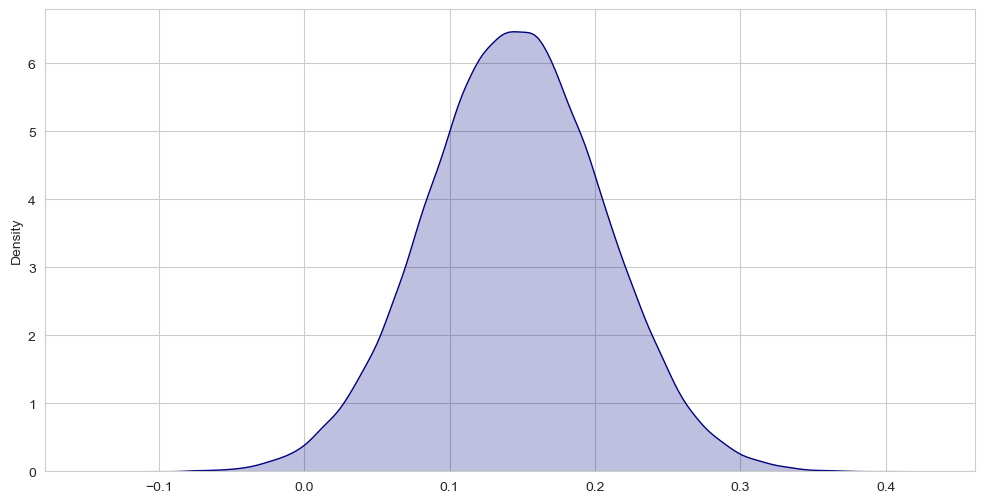

In [71]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(sim_port_sharpe, fill=True, color='navy')

<Axes: ylabel='Density'>

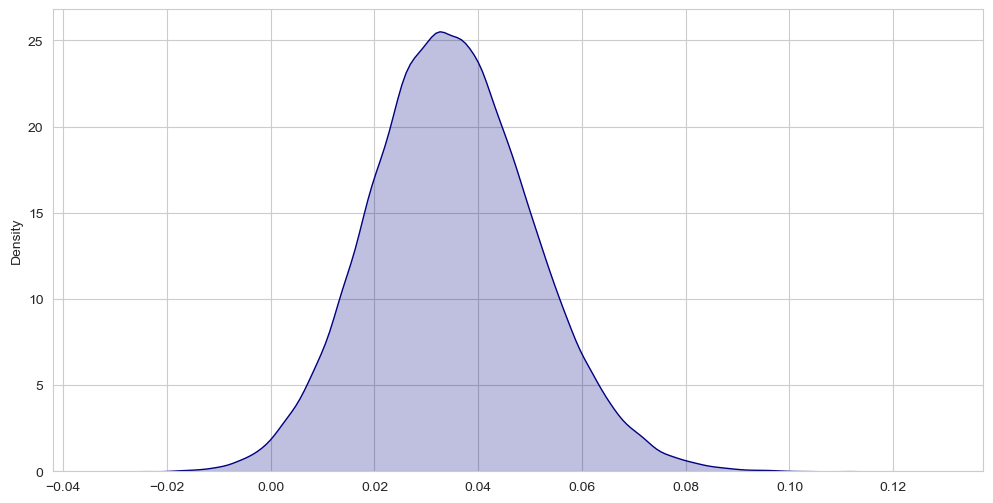

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(sim_port_geo_ret, fill=True, color='navy')

# Problem 2: Adding an investment to existing portfolio

## Simulate equity prices, short rates and bond prices

### Simulate risk drivers

In [64]:
"""
Initialize parameters for simulation
"""

np.random.seed(222)

# equity parameters
sigma = 0.15
mu = 0.06

# short rate parameters
initial_rate = 0.03
kappa = 1.0
theta = 0.03
beta = 0.02
rp = -0.2

# correlation
rho = -0.2

# simulation definition
num_sim = 10_000
dt = 1.0 / 12.0 
horizon = 5.0 
num_time_steps = int(horizon / dt)
time_points = np.arange(0, num_time_steps + 1, 1) * dt

In [57]:
import numpy as np
np.random.seed(222)


"""
Initialize parameters for simulation
"""

# equity parameters
sigma = 0.005705482064922983
mu = 0.0001876482646574682

from codelib.Models.vasicek_model import VasicekModel
short_rate = "/Users/osito/Repositories/AEF_thesis_GBI/Miscellaneous/Archive/Data/short_rate.xlsx"


vas = VasicekModel(short_rate,252)
initial_rate=vas.rates.iloc[-1]
kappa, theta, beta = vas.estimate_params()

rp = -0.2

# correlation
rho = 0.6

# simulation definition
num_sim = 10_000
dt = 1.0 / 252
horizon = 10
num_time_steps = int(horizon / dt)
time_points = np.arange(0, num_time_steps + 1, 1) * dt

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.231e+06
Date:                Thu, 20 Mar 2025   Prob (F-statistic):               0.00
Time:                        08:10:33   Log-Likelihood:                 2609.9
No. Observations:                1986   AIC:                            -5216.
Df Residuals:                    1984   BIC:                            -5205.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.002      1.105      0.2

In [58]:
"""
Define functions for simulation
"""

def simulate_vasicek(initial_short_rate: float, kappa: float, theta: float, beta: float, horizon: float, 
                     dt: float=1.0/12, num_sim: int=10000, z_mat=None):
    """
    simulates short rate processes in a vasicek setting until a given horizon 
    
    Parameters
    ----------
    
    initial_short_rate:
        initial short rate
    kappa: 
        speed of mean reversion.
    theta: 
        long term mean of the short rate.
    dt:
        increments in time
    horizon:
        time until maturity/expiry (horizon).
    num_sim:
        number of simulations.
    """
    std_rates = np.sqrt(beta**2 / (2 * kappa) * (1 - np.exp(-2 * kappa * dt)))
    
    num_periods = int(horizon / dt)
    short_rates = np.empty((num_sim, num_periods + 1))
    short_rates[:, 0] = initial_short_rate

    if z_mat is None:
        error_terms = np.random.normal(scale=std_rates, size=(num_sim, num_periods))
    else: 
        error_terms = std_rates * z_mat
    
    for i in range(1, num_periods + 1): 
        
        short_rates[:, i] = theta + (short_rates[:, i - 1] - theta) * np.exp(-kappa * dt) + error_terms[:, i - 1]

    return short_rates


def simulate_risk_drivers(mu: float, sigma: float,
                          initial_rate: float, kappa: float, theta: float, beta: float,
                          rho: float,
                          horizon: float, 
                          dt: float=1.0 / 12,
                          num_sim: int=10_000): 
    
    """
    Function simulating the risky asset and the short rate. 
    """

    # define the number of time steps
    num_time_steps = int(horizon / dt)

    # convert parameters of equity values
    mu_scaled = (mu - 0.5 * sigma**2) * dt
    sigma_scaled = sigma * np.sqrt(dt)

    # define innovation correlation matrix
    z_corr_mat = np.array([[1.0, rho], [rho, 1.0]])

    # simulate innovations
    z_mat = np.random.multivariate_normal(np.zeros(2), z_corr_mat, size=(num_sim, num_time_steps))
    
    # simulate equity prices 
    log_ret = mu_scaled + sigma_scaled * z_mat[:, :, 0]
    
    equity_prices = np.ones((num_sim, num_time_steps + 1))
    equity_prices[:, 1:] = np.exp(np.cumsum(log_ret, axis=1))

    # simulate short rates 
    short_rates = simulate_vasicek(initial_short_rate=initial_rate,
                                   kappa=kappa,
                                   theta=theta,
                                   beta=beta,
                                   horizon=horizon, 
                                   dt=dt,
                                   num_sim=num_sim,
                                   z_mat=z_mat[:, :, 1])
    
    return equity_prices, short_rates



In [65]:
"""
Simulate risk drivers
"""

equity_prices, short_rates = simulate_risk_drivers(mu, sigma,
                                                   initial_rate, kappa, theta, beta,
                                                   rho,
                                                   horizon, 
                                                   dt,
                                                   num_sim)

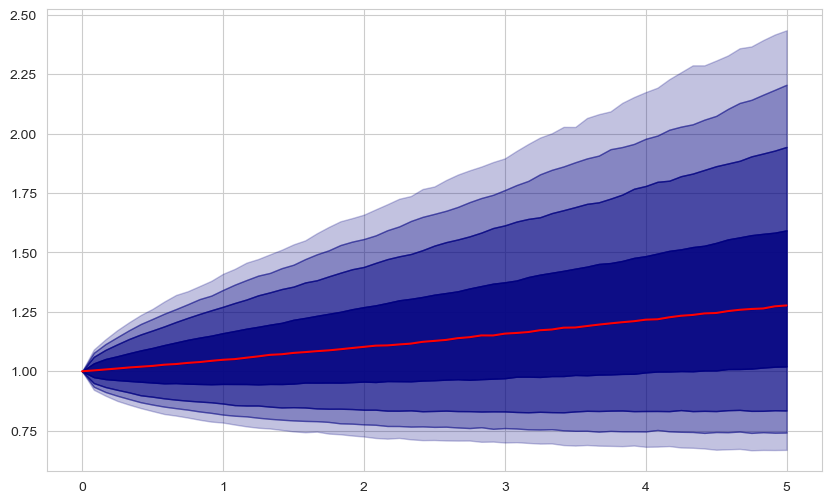

In [66]:
"""
Plot fan chart of short rates
"""
percentiles = np.percentile(equity_prices, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

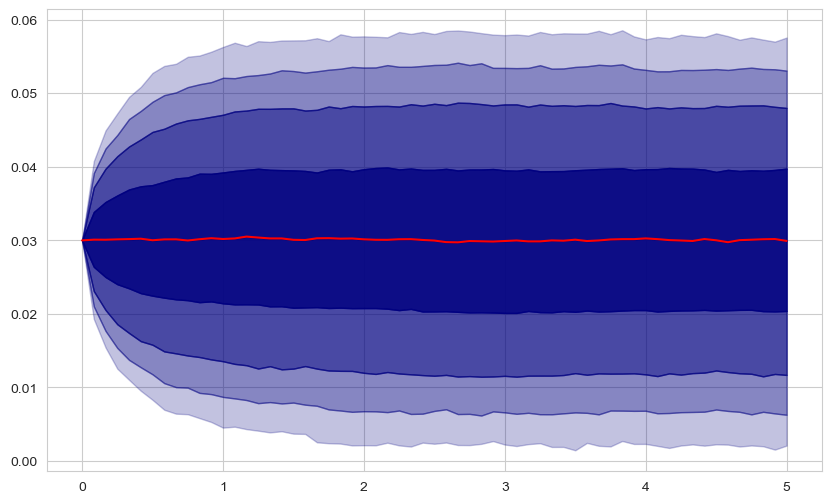

In [67]:
"""
Plot fan chart of short rates
"""
percentiles = np.percentile(short_rates, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

### Simulate Zero Coupon bond prices

In [68]:
"""
Define functions for calculating zero coupon bond prices
"""


def calculate_zero_coupon_yield(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float): 
    
    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)
    
    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2
    
    return (a + b * initial_short_rate) / time_to_maturity

def calculate_zero_coupon_price(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float):
    
    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)
    
    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2
    
    return np.exp(- a - b * initial_short_rate)

In [71]:
"""
Simulate zero coupon bond yields for maturities 10y and 10y - delta t
"""

zcb_10y_mv = np.zeros((num_sim, num_time_steps + 1))
zcb_10y_minus_delta_t = np.zeros((num_sim, num_time_steps + 1))

for i, t in enumerate(time_points):
    zcb_10y_mv[:, i] = calculate_zero_coupon_yield(10.0, short_rates[:, i], kappa, theta, beta, rp)
    zcb_10y_minus_delta_t[:, i] = calculate_zero_coupon_yield(10.0 - dt, short_rates[:, i], kappa, theta, beta, rp)

In [69]:
"""
Simulate zero coupon bond prices for maturities 10y and 10y - delta t
"""


zcb_10y_mv = np.zeros((num_sim, num_time_steps + 1))
zcb_10y_minus_delta_t = np.zeros((num_sim, num_time_steps + 1))

for i, t in enumerate(time_points):
    zcb_10y_mv[:, i] = calculate_zero_coupon_price(10.0, short_rates[:, i], kappa, theta, beta, rp)
    zcb_10y_minus_delta_t[:, i] = calculate_zero_coupon_price(10.0 - dt, short_rates[:, i], kappa, theta, beta, rp)

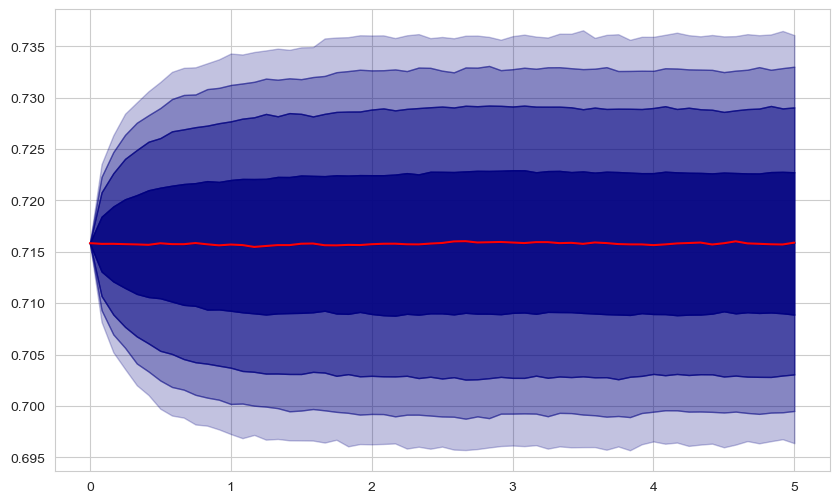

In [70]:
"""
Plot fan chart of zero coupon bond prices
"""
percentiles = np.percentile(zcb_10y_mv, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

### Calculate portfolio value

In [83]:
init_wealth = 100e6
eq_w = 0.6
zcb_w = 0.4

In [84]:
"""
Calculate return of bond and equity
"""
eq_ret = equity_prices[:, 1:] / equity_prices[:, :-1] - 1.0
zcb_ret = zcb_10y_minus_delta_t[:, 1:] / zcb_10y_mv[:, :-1] - 1.0
port_ret = eq_w * eq_ret + zcb_w * zcb_ret

In [85]:
eq_ret

array([[-0.05279574,  0.01622969,  0.05069633, ...,  0.00456282,
        -0.00935075,  0.07464519],
       [-0.03538009,  0.02035855,  0.00784493, ..., -0.05128982,
         0.0281134 , -0.00353947],
       [ 0.09938712, -0.03158713,  0.00213367, ...,  0.01168047,
         0.02820332,  0.04671484],
       ...,
       [-0.04362083,  0.00371163, -0.03291363, ..., -0.0857294 ,
        -0.03975048,  0.02914806],
       [-0.00302576,  0.00960696,  0.03056992, ...,  0.03762665,
         0.01763296, -0.00207713],
       [-0.06104576,  0.04732335, -0.05531583, ...,  0.00465978,
         0.09568928, -0.01878175]])

In [86]:
"""
Calculate portfolio value
"""

port_value = np.c_[init_wealth * np.ones(num_sim), init_wealth * np.cumprod( 1 + port_ret, axis=1)]

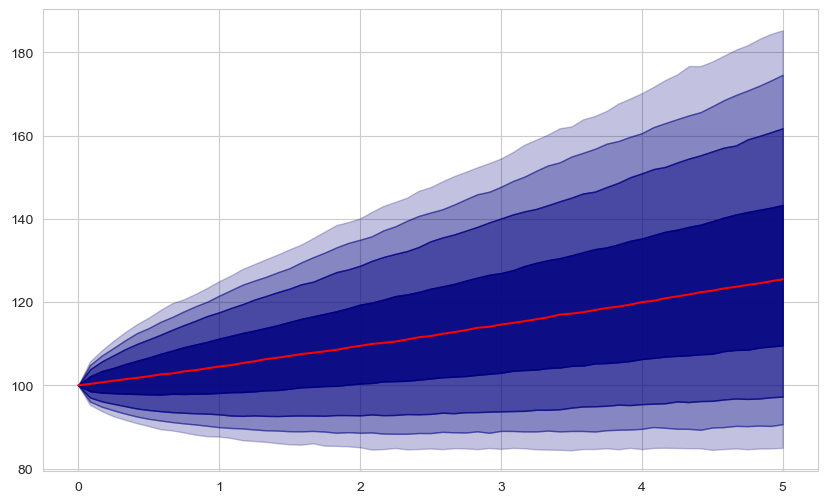

In [87]:
"""
Plot fan chart of zero coupon bond prices
"""
percentiles = np.percentile(port_value / 1e6, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

## Two investment strategies

In [88]:
"""
Define functions for calculating zero coupon bond prices with spread
"""


def calculate_zero_coupon_yield_with_spread(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float,
                                spread: float): 
    
    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)
    
    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2
    
    return (a + b * initial_short_rate) / time_to_maturity + spread

def calculate_zero_coupon_price_with_spread(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float,
                                spread):
    
    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)
    
    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2
    
    return np.exp(- a - b * initial_short_rate - spread * time_to_maturity)

### Expected cash flows at time zero 

The expected value of the equity value at time $t$ is equal to $V_{Eq, t} e^{(T - t) \mu}$. Thus, we have the cash flow as written below.

In [91]:
"""
Define initial expected cash flows
"""

cf_time_points=np.array([1.0, 2.0, 3.0, 4.0, 5.0])
expected_flows_1 = np.array([10.0, 10.0, 10.0, 10.0, 10.0])
expected_flows_2 = np.array([10.0, 10.0, 10.0, 10.0, 10.0])

init_expected_cash_flow_1 = CashFlow(time_points=np.array([1.0, 2.0, 3.0, 4.0, 5.0]), flows=expected_flows_1)
init_expected_cash_flow_2 = CashFlow(time_points=np.array([1.0, 2.0, 3.0, 4.0, 5.0]), flows=expected_flows_2)

In [93]:
"""
Present value
"""

spread = 300 / 100 / 100

discount_factors_t0 = calculate_zero_coupon_price_with_spread(cf_time_points, short_rates[0, 0], kappa, theta, beta, rp, spread)

mv_1 = discount_factors_t0 @ init_expected_flows_1
mv_2 = discount_factors_t0 @ init_expected_flows_2

ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

In [477]:
mv_1

41.59296589002812

In [478]:
mv_2

41.59296589002812

In [479]:
"""
Internal rate of return
"""

irr_1 = init_expected_cash_flow_1.internal_rate_of_return(market_value=mv_1)
irr_2 = init_expected_cash_flow_2.internal_rate_of_return(market_value=mv_2)

In [480]:
irr_1

0.062672133507931

In [481]:
irr_2

0.062672133507931

### Realized Cash Flows

In [482]:
week_idx = (cf_time_points / dt).astype(int)

In [494]:
realized_flows_1 = 10 + 5 * (equity_prices[:, week_idx] - np.exp(mu * cf_time_points)[None, :])
realized_flows_2 = 10 - 2.5 * (equity_prices[:, week_idx] - np.exp(mu * cf_time_points)[None, :])

In [495]:
realized_flows_1

array([[ 8.3310726 ,  8.24582897,  9.40347893,  8.64926976,  7.76423822],
       [10.97492284, 10.07138593, 10.80144661, 10.84651196,  9.61645971],
       [ 8.64217059,  7.75699673,  7.14647254,  7.11895964,  6.26877285],
       ...,
       [10.61835384, 10.32642912, 11.96011858, 13.97690971, 13.78107997],
       [ 9.71363807,  9.85971743, 10.55353669,  9.6718323 , 11.48910047],
       [10.07939102,  8.72977472,  8.66197218,  8.72635793,  8.11234531]])

In [498]:
realized_irr_1 = []
realized_irr_2 = []

for s in range(num_sim): 
    
    cf_temp1 = CashFlow(time_points=cf_time_points, flows=realized_flows_1[s, :])
    cf_temp2 = CashFlow(time_points=cf_time_points, flows=realized_flows_2[s, :])
    
    realized_irr_1.append(cf_temp1.internal_rate_of_return(market_value=mv_1, lower_limit= -2.0, upper_limit= 2.0))
    realized_irr_2.append(cf_temp2.internal_rate_of_return(market_value=mv_2, lower_limit= -2.0, upper_limit= 2.0))

realized_irr_1 = np.array(realized_irr_1)
realized_irr_2 = np.array(realized_irr_2)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

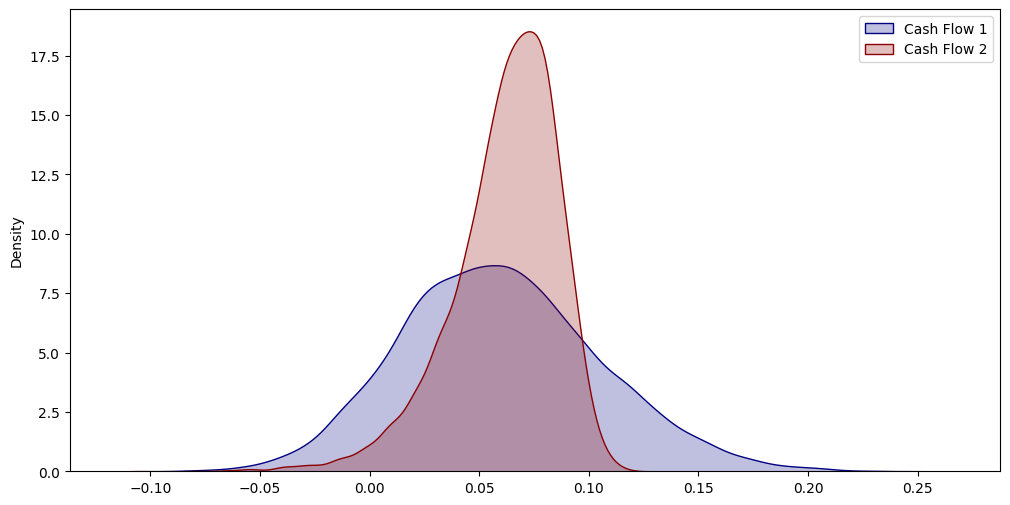

In [505]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(realized_irr_1, fill=True, color='navy', ax=ax, label="Cash Flow 1")
sns.kdeplot(realized_irr_2, fill=True, color='darkred', ax=ax, label="Cash Flow 2")

ax.legend();

### Portfolio effect

In [507]:

realized_mv_1 = np.zeros((num_sim, len(time_points)))
realized_mv_1[:, 0] = mv_1

realized_mv_2 = np.zeros((num_sim, len(time_points)))
realized_mv_2[:, 0] = mv_1

In [538]:
def calculate_zero_coupon_price_with_spread_vectorized(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: Union[float, np.ndarray],
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float,
                                spread):
    
    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)
    
    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2
    
    return np.exp(- a - b * initial_short_rate[:, None] - spread * time_to_maturity)

In [548]:
"""
Calculate market value of future expected cash flows
"""

expectation_equity = np.exp(mu * cf_time_points)

for i, t in enumerate(time_points[:-1]): 
    # indicator to select cash flow and time points
    adj_cf_time_points = (cf_time_points - t)
    indicator = adj_cf_time_points > 0

    # adjusted time points
    adj_cf_time_points = adj_cf_time_points[indicator]

    # relevant initial equity expectations
    adj_init_expectation_equity = expectation_equity[indicator]
    
    # expected future cash flow
    expected_future_cash_flow_1 = 10 + 5 * (np.outer(equity_prices[:, i], np.exp(mu * adj_cf_time_points)) - adj_init_expectation_equity[None, :])
    expected_future_cash_flow_2 = 10 - 2.5 * (np.outer(equity_prices[:, i], np.exp(mu * adj_cf_time_points)) - adj_init_expectation_equity[None, :])
        
    # calculate discount vectors
    discounter_vectors = calculate_zero_coupon_price_with_spread_vectorized(adj_cf_time_points, short_rates[:, i], kappa, theta, beta, rp, spread)

    # calculate market values
    realized_mv_1[:, i] = np.sum(discounter_vectors * expected_future_cash_flow_1, axis=1)
    realized_mv_2[:, i] = np.sum(discounter_vectors * expected_future_cash_flow_2, axis=1)

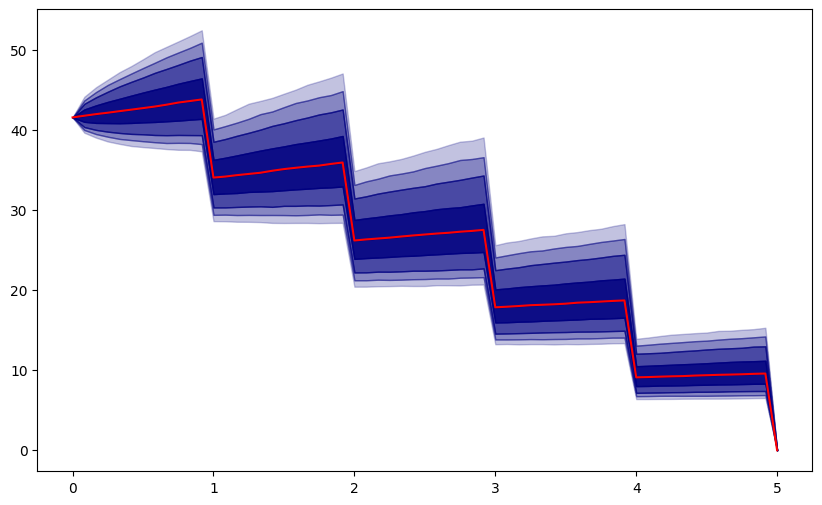

In [550]:
"""
Plot fan chart of cash flow market values
"""
percentiles = np.percentile(realized_mv_1, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

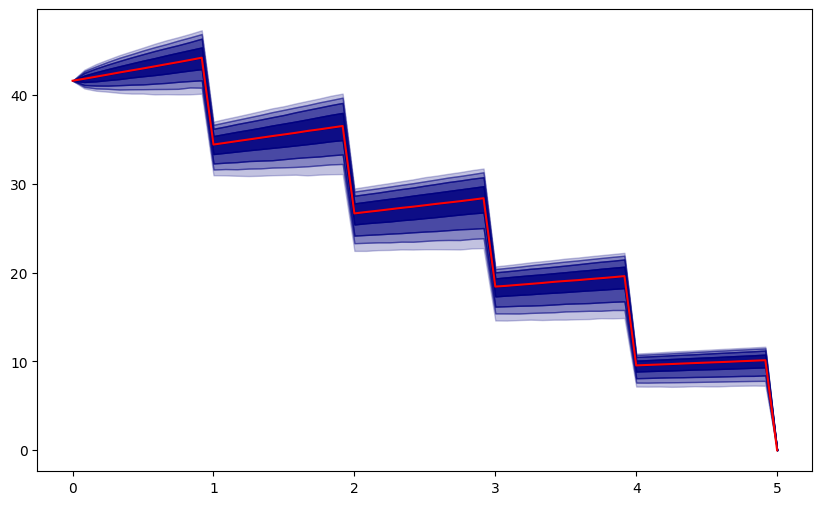

In [551]:
"""
Plot fan chart of cash flow market values
"""
percentiles = np.percentile(realized_mv_2, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

In [ ]:
"""
Simulate value of portfolio with the two different investments
"""

In [561]:
port_value_1 = np.zeros((num_sim, len(time_points)))
port_value_1[:, 0] = init_wealth / 1e6

asset_value_1 = np.zeros((num_sim, len(time_points)))
asset_value_1[:, 0] = port_value_1[:, 0] - realized_mv_1[:, 0]

port_value_2 = np.zeros((num_sim, len(time_points)))
port_value_2[:, 0] = init_wealth / 1e6

asset_value_2 = np.zeros((num_sim, len(time_points)))
asset_value_2[:, 0] = port_value_2[:, 0] - realized_mv_2[:, 0]

idx = 0
for i, t in enumerate(time_points[1:], start=1): 

    asset_value_1[:, i] = asset_value_1[:, i - 1] * (1 + port_ret[:, i - 1])
    asset_value_2[:, i] = asset_value_2[:, i - 1] * (1 + port_ret[:, i - 1])

    if i in week_idx: 

        asset_value_1[:, i] += realized_flows_1[:, idx]
        asset_value_2[:, i] += realized_flows_2[:, idx]

        idx += 1

    port_value_1[:, i] = asset_value_1[:, i] + realized_mv_1[:, i]
    port_value_2[:, i] = asset_value_2[:, i] + realized_mv_2[:, i]
    

In [566]:
port_value_scaled = port_value / 1e6

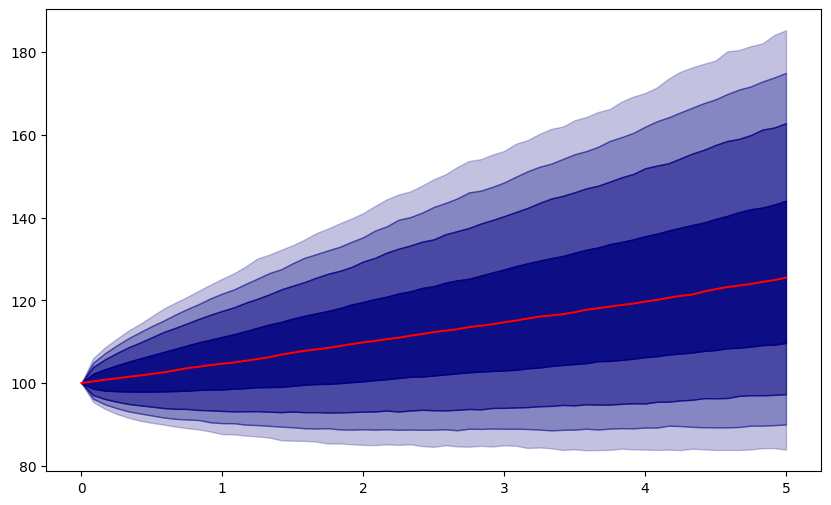

In [570]:
"""
Plot fan chart of initial portfolio
"""
percentiles = np.percentile(port_value_scaled, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

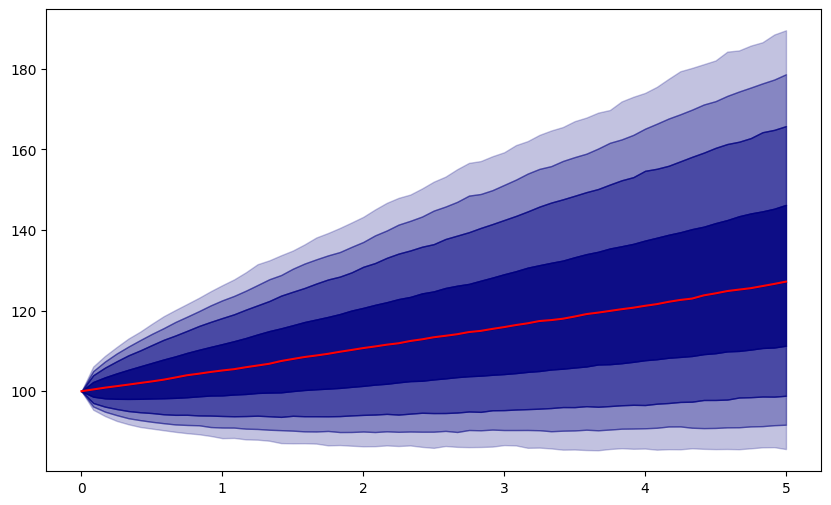

In [562]:
"""
Plot fan chart of portfolio with investment 1
"""
percentiles = np.percentile(port_value_1, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

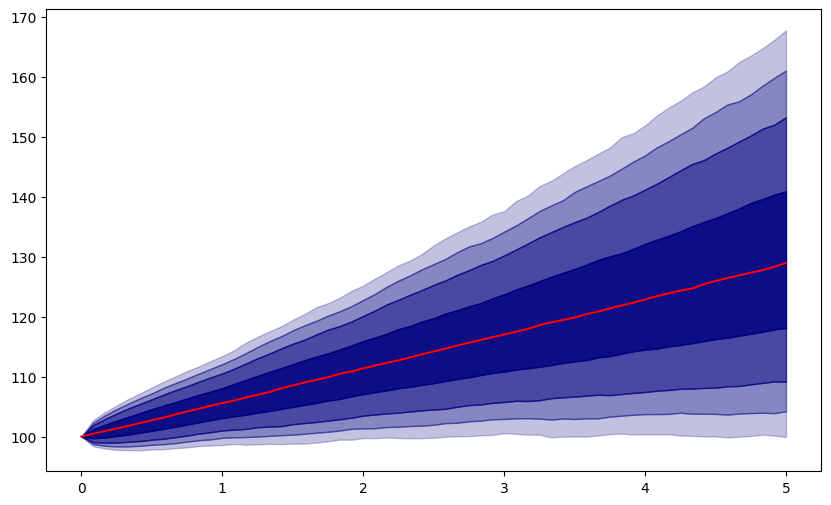

In [563]:
"""
Plot fan chart of portfolio with investment 2
"""
percentiles = np.percentile(port_value_2, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

### Evaluation

In [568]:
df_eval = pd.DataFrame(index=['Expectation', 'Std.', 'CVaR'], columns=['Initial portfolio', 'Investment 1', 'Investment 2'], 
                       data = np.array([[np.mean(port_value_scaled[:, -1]), np.mean(port_value_1[:, -1]), np.mean(port_value_2[:, -1])], 
                                        [np.std(port_value_scaled[:, -1]), np.std(port_value_1[:, -1]), np.std(port_value_2[:, -1])], 
                                        [rm.calculate_conditional_value_at_risk(port_value_scaled[:, -1], p=0.05), rm.calculate_conditional_value_at_risk(port_value_1[:, -1], p=0.05), rm.calculate_conditional_value_at_risk(port_value_2[:, -1], p=0.05)]]))

In [569]:
df_eval

,Initial portfolio,Investment 1,Investment 2
Expectation,128.192924,130.260159,130.211773
Std.,26.085723,26.763238,17.292039
CVaR,82.699599,84.565920,98.818144
